# Demo for Patch data
VR 2025-01-08

In [1]:
import retinanalysis as ra
import matplotlib.pyplot as plt
import numpy as np

/home/vyomr/anaconda3/envs/torch/lib/python3.12/site-packages/datajoint/settings.py:992: UserWarning: No datajoint.json found. Using defaults and environment variables. Run `dj.config.save_template()` to create a template configuration.
  config = _create_config()


Parse h5 to json, then place h5 and json in database dirs, then populate database.

In [2]:
# ra.populate_database()

In [3]:
# I'm querying all patch experiments to find an example
ra.schema.Experiment() & 'is_mea=0'

[2026-06-16 15:54:11] DataJoint 2.2.2 connected to root@127.0.0.1:3306


id,h5_uuid,exp_name,meta_file,data_file,tags_file,is_mea,date_added,label,properties,attributes,start_time,experimenter,institution,lab,project,rig,rig_type
182,67cdd3fc-5cf0-42b2-85b3-daa1fc7a8705,2026-01-02_E_2,/mnt/Volumes/data-1/datajoint_testbed/mea/meta/2026-01-02_E_2.json,/mnt/Volumes/data-1/data/h5/2026-01-02_E_2.h5,/mnt/Volumes/data-1/datajoint_testbed/mea/tags/2026-01-02_E_2.json,0,2026-06-16 14:59:38,Primate,json,json,2026-01-02 16:17:39,None,None,None,None,None,PATCH
190,7638a0a7-98a1-4027-849f-454c5180718f,2026-03-03_E,/mnt/Volumes/data-1/datajoint_testbed/mea/meta/2026-03-03_E.json,/mnt/Volumes/data-1/data/h5/2026-03-03_E.h5,/mnt/Volumes/data-1/datajoint_testbed/mea/tags/2026-03-03_E.json,0,2026-06-16 15:03:39,Primate,json,json,2026-03-03 08:37:01,None,None,None,None,None,PATCH
191,a25411a5-4c23-4f70-afa0-c7553b983425,2026-03-10_E,/mnt/Volumes/data-1/datajoint_testbed/mea/meta/2026-03-10_E.json,/mnt/Volumes/data-1/data/h5/2026-03-10_E.h5,/mnt/Volumes/data-1/datajoint_testbed/mea/tags/2026-03-10_E.json,0,2026-06-16 15:03:59,Primate,json,json,2026-03-10 10:15:03,None,None,None,None,None,PATCH
192,d6ba11be-e4c5-45a3-8347-7e74c492657d,2026-03-09_E,/mnt/Volumes/data-1/datajoint_testbed/mea/meta/2026-03-09_E.json,/mnt/Volumes/data-1/data/h5/2026-03-09_E.h5,/mnt/Volumes/data-1/datajoint_testbed/mea/tags/2026-03-09_E.json,0,2026-06-16 15:04:23,Primate,json,json,2026-03-09 09:03:10,None,None,None,None,None,PATCH
196,3a5a4065-52fc-49cd-8f48-0eb7d114a07c,2026-03-18_E,/mnt/Volumes/data-1/datajoint_testbed/mea/meta/2026-03-18_E.json,/mnt/Volumes/data-1/data/h5/2026-03-18_E.h5,/mnt/Volumes/data-1/datajoint_testbed/mea/tags/2026-03-18_E.json,0,2026-06-16 15:06:33,Primate,json,json,2026-03-18 09:02:41,None,None,None,None,None,PATCH
200,37ae31c9-d19d-4004-a2a9-992f42b52b4b,2026-04-03_E,/mnt/Volumes/data-1/datajoint_testbed/mea/meta/2026-04-03_E.json,/mnt/Volumes/data-1/data/h5/2026-04-03_E.h5,/mnt/Volumes/data-1/datajoint_testbed/mea/tags/2026-04-03_E.json,0,2026-06-16 15:08:23,Primate,json,json,2026-04-03 10:31:57,None,None,None,None,None,PATCH


In [4]:
exp_name = '2026-01-02_E_2'
df_exp = ra.get_exp_summary(exp_name)

For Cell1 ON-Parasol let's get the expanding spots data

In [5]:
cell_label = 'Cell7'
df_c7 = df_exp.query('cell_label == @cell_label')
df_c7[['protocol_name', 'block_id']]

,protocol_name,block_id
0,edu.washington.riekelab.turner.protocols.Split...,4240
1,edu.washington.riekelab.turner.protocols.Split...,4241
2,edu.washington.riekelab.turner.protocols.Expan...,4242
3,edu.washington.riekelab.protocols.SingleSpot,4243
4,manookinlab.protocols.DovesMovie,4244
5,manookinlab.protocols.DovesMovie,4245
6,edu.washington.riekelab.protocols.SingleSpot,4246
7,edu.washington.riekelab.protocols.SingleSpot,4247
8,manookinlab.protocols.DovesMovie,4248
9,manookinlab.protocols.DovesMovie,4249


In [6]:
# Block ID from table above, or can query by protocol name etc.
block_id = 4242
sb = ra.StimBlock(exp_name, block_id)

# Note we're using SCResponseBlock. b_spiking=True will run spike detection.
rb = ra.SCResponseBlock(exp_name, block_id, b_spiking=True)

Initializing StimBlock for 2026-01-02_E_2 block 4242
For Rig E 2026-01-02_E_2, assuming ConfocalWithLightCrafterAbove rig config:
Found stage frame rate 60.0 for experiment 2026-01-02_E_2
{'disp_type': 'LCR', 'mu_per_pixel': 1.3, 'n_ht': 1140, 'n_wt': 1824, 'mean_frame_rate': 59.9422, 'stage_frame_rate': np.float64(60.0)}
Initializing ResponseBlock for 2026-01-02_E_2 block 4242
If this is for an LED stimulus, be sure to set b_LED=True!

Error occurred while getting actual onset/offset times: unsupported operand type(s) for *: 'float' and 'NoneType'
It could be that frame_times_ms do not have the correct number of frames due to some error in frame detection.
Check the frame monitor sample rate! On MEA Rigs, prefer 1k, errors likely with 10k.
Loading frame monitor data from /mnt/Volumes/data-1/data/h5/2026-01-02_E_2.h5 ...
Loaded (33, 7500) frame_data.

Loading Amp1 data from /mnt/Volumes/data-1/data/h5/2026-01-02_E_2.h5 ...
Loaded (33, 7500) amp_data.

Max trial length in data points: 1

In [7]:
rb

SCResponseBlock with properties:
  exp_name: 2026-01-02_E_2
  block_id: 4242
  b_LED: False (whether response to LED stimulus)
  protocol_name: edu.washington.riekelab.turner.protocols.ExpandingSpots  d_timing with keys: ['exp_name', 'block_id', 'frameTimesMs', 'n_epochs', 'pre_time_ms', 'stim_time_ms', 'tail_time_ms', 'stage_frame_rate', 'actual_onset_times_ms', 'actual_offset_times_ms']
  frame_sample_rate: 10000.0 Hz
  frame_data shape: (33, 7500)
  b_spiking: True
  amp_data shape: (33, 7500)
  amp_sample_rate: 10000.0 Hz
  spike_times length: 33
  spike_amps length: 33
  spike_refs length: 33

## Plot example trace and summary spikes

In [10]:
sb.df_epochs.head()

,epoch_index,currentSpotSize,exp_name,group_label,protocol_name,frame_times_ms,epoch_parameters,preTime,stimTime,tailTime,experiment_id,group_id,block_id,protocol_id,epoch_id
0,0,25.0,2026-01-02_E_2,Control,edu.washington.riekelab.turner.protocols.Expan...,"[0.0, 17.0, 34.0, 50.0, 67.0, 84.0, 100.0, 117...","{'NDF': 0.0, 'amp': 'Amp1', 'gain': None, 'ndf...",250.0,250.0,250.0,182,2859,4242,83,292054
1,1,50.0,2026-01-02_E_2,Control,edu.washington.riekelab.turner.protocols.Expan...,"[0.0, 17.0, 34.0, 50.0, 67.0, 84.0, 100.0, 117...","{'NDF': 0.0, 'amp': 'Amp1', 'gain': None, 'ndf...",250.0,250.0,250.0,182,2859,4242,83,292055
2,2,100.0,2026-01-02_E_2,Control,edu.washington.riekelab.turner.protocols.Expan...,"[0.0, 17.0, 34.0, 50.0, 67.0, 84.0, 100.0, 117...","{'NDF': 0.0, 'amp': 'Amp1', 'gain': None, 'ndf...",250.0,250.0,250.0,182,2859,4242,83,292056
3,3,150.0,2026-01-02_E_2,Control,edu.washington.riekelab.turner.protocols.Expan...,"[0.0, 17.0, 34.0, 50.0, 67.0, 84.0, 100.0, 117...","{'NDF': 0.0, 'amp': 'Amp1', 'gain': None, 'ndf...",250.0,250.0,250.0,182,2859,4242,83,292057
4,4,200.0,2026-01-02_E_2,Control,edu.washington.riekelab.turner.protocols.Expan...,"[0.0, 17.0, 34.0, 50.0, 67.0, 84.0, 100.0, 117...","{'NDF': 0.0, 'amp': 'Amp1', 'gain': None, 'ndf...",250.0,250.0,250.0,182,2859,4242,83,292058


In [11]:
spot_sizes = sb.df_epochs['currentSpotSize'].values

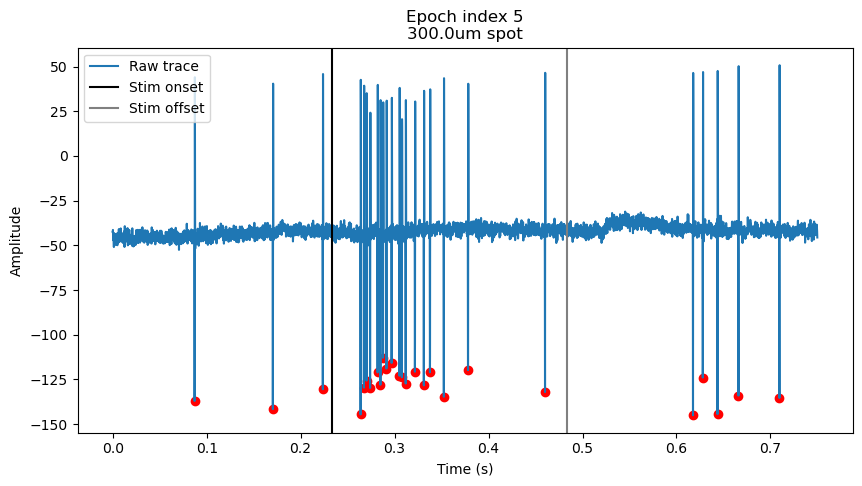

In [16]:
# Example trace from 3rd epoch
def plot_eg_trace(rb, sb, i_epoch):
    f, ax = plt.subplots(1, 1, figsize=(10, 5))
    raw = rb.amp_data[i_epoch]
    sts = rb.spike_times[i_epoch]
    time = np.arange(len(raw)) / rb.amp_sample_rate
    ax.plot(time, raw, label='Raw trace')
    ax.scatter(sts/rb.amp_sample_rate, raw[sts], color='r')
    pre_time = sb.df_epochs.at[i_epoch, 'preTime']
    # Hacky correction for first missing frame. Need to implement frame monitor based timing.
    pre_time -= 1/60 * 1000
    stim_time = sb.df_epochs.at[i_epoch, 'stimTime']
    offset_time = pre_time + stim_time
    ax.axvline(pre_time / 1000, c='k', label='Stim onset')
    ax.axvline(offset_time / 1000, c='grey', label='Stim offset')
    spot_size = sb.df_epochs.at[i_epoch, 'currentSpotSize']
    ax.set_title(f'Epoch index {i_epoch}\n{spot_size}um spot')
    ax.set_xlabel('Time (s)')
    ax.set_ylabel('Amplitude')
    ax.legend()

i_epoch = 5
plot_eg_trace(rb, sb, i_epoch)

In [13]:
def get_stim_nspikes(sb, rb, b_sub_baseline: bool=False):
    ls_nsps = []
    for e_idx in sb.df_epochs.index:
        pre_time = sb.df_epochs.at[e_idx, 'preTime']
        
        # Hacky correction for first missing frame. Need to implement frame monitor based timing.
        pre_time -= 1/60 * 1000
        stim_time = sb.df_epochs.at[e_idx, 'stimTime']
        offset_time = pre_time + stim_time
        # Convert from ms to samples
        onset_samples = int(np.round(pre_time * rb.amp_sample_rate / 1000))
        offset_samples = int(np.round(offset_time * rb.amp_sample_rate / 1000))
        sts = rb.spike_times[e_idx]
        n_sps = len(sts[(sts >= onset_samples) & (sts <= offset_samples)])
        if b_sub_baseline:
            n_baseline = len(sts[(sts < onset_samples)])
            n_sps -= n_baseline
        ls_nsps.append(n_sps)
    stim_spikes = np.array(ls_nsps)

    return stim_spikes

stim_spikes = get_stim_nspikes(sb, rb, b_sub_baseline=False)

Text(0, 0.5, 'Number of spikes during spot flash period')

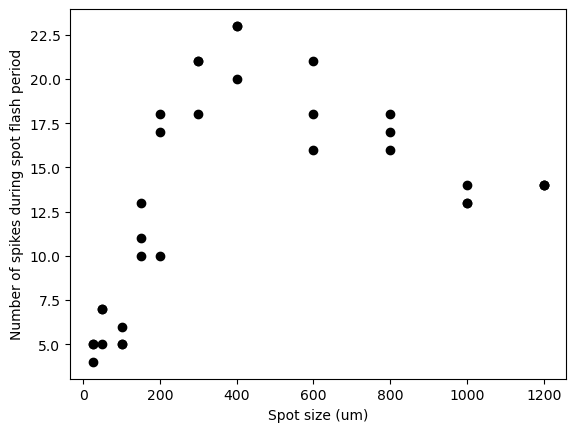

In [14]:
plt.scatter(spot_sizes, stim_spikes, c='k')
plt.xlabel('Spot size (um)')
plt.ylabel('Number of spikes during spot flash period')